In [ ]:
# используйте pymorphy3!

In [ ]:
!pip install razdel pymorphy3

In [ ]:
!pip install pymorphy3 razdel nltk
!python -m pymorphy3 download dicts

In [4]:
import nltk

In [ ]:
nltk.download('punkt')

In [ ]:
nltk.download('punkt_tab')

# Задание 1.

Разбейте текст ниже на предложения с помощью библиотеки razdel. Токенизируйте 15-е (индекс 14 если считать с 0) предложение с помощью word_tokenizer из nltk.
Разберите каждый отдельный токен этого предложения через pymorphy. Для каждого слова выберите последний по вероятности доступный разбор (если разбор только один, то выберите его) и выделите только части речи. Посчитайте сколько раз встречается тэг NOUN. Получившееся число вставьте в форму

In [9]:
text = """
Мне кажется, это важно проговорить

Месси делает невероятное. Мы никогда не видели человека, который бы ТАК (!) постиг игру.Превратив ее из сложной математической формулы в сердечко на асфальте.

Но прелесть Аргентины в том, что даже такой игрок–лишь часть чего-то большего.

Эта команда может обороняться вдесятером, пока Месси копит силы.Крепкая Австрия со своим прессингом не создала почти ничего!!!

Де Поль успевает раздавать передачи в стиле Хави,потом пробежать 30 метров, чтобы оказать давление на соперника, затем 30 метров назад, чтобы закрыть зону в обороне, которую Месси не закроет. Энцо Фернандес сохраняет мяч под давлением со спокойствием мажора, которого не избаловали. Мак Аллистер играет как два опорника.
Каждый в этой Аргентине техничен и умен. Минимум технического брака, минимум странных решений даже в микромоментах. Если выносят, так четко и наотмашь. Если фолят, так умело, что в голове судьи – синий экран: это желтая или не желтая? Если отдают под давлением, то в дальнюю ногу, что не отберешь, если не сфолишь.

Не футболисты – банда из Буэнос-Айреса. Хитрые, злые, умелые.
Эта команда может две минуты игнорировать лучшего игрока в истории, чтобы взорваться за 10 секунд и провести вертикальную атаку, будто прессинг Австрии какая-то шутка.

А в 2022-м это была еще более вертикальная команда, потому что меньше дорожила мячом как инструментом обороны. Потому что Месси тогда был сильнее и опаснее. Риск был оправдан. Сейчас она осторожнее и бережливее. К себе и тому, кто делает невероятное.

Эта команда интуитивно понимает, как прикрывать главную уязвимость (Месси в обороне). В каждом единоборстве. Когда сфолить, куда добежать, как расставиться, кому подстраховать. Такому можно научить только через культуру, через тысячи дворов меж узких улочек. Такое можно только вспомнить.

Эта команда Лионеля Скалони.

"""

In [7]:
# используйте pymorphy3
from pymorphy3 import MorphAnalyzer
import nltk
from razdel import sentenize
from nltk.tokenize import word_tokenize
import pymorphy3


In [15]:
sentences = list(sentenize(text))
print(sentences[14])

Substring(1104, 1271, 'Эта команда может две минуты игнорировать лучшего игрока в истории, чтобы взорваться за 10 секунд и провести вертикальную атаку, будто прессинг Австрии какая-то шутка.')


In [17]:
print(f"15е предложение: {sentences[14].text}")

fifteenth_sentence = sentences[14].text
tokens = word_tokenize(fifteenth_sentence, language='russian')
print(tokens)

morph = pymorphy3.MorphAnalyzer()
pos_tags = []
for token in tokens:
    if token in ('.', ',', '!', '?', ';', ':', '–', '(', ')', '"', "'"):
        continue
    parsed = morph.parse(token)
    if parsed:
        last_parsed = parsed[-1]
        pos = last_parsed.tag.POS
        if pos is not None:
            pos_tags.append(pos)

print(pos_tags)

noun_count = pos_tags.count('NOUN')
print(noun_count)


15е предложение: Эта команда может две минуты игнорировать лучшего игрока в истории, чтобы взорваться за 10 секунд и провести вертикальную атаку, будто прессинг Австрии какая-то шутка.
['Эта', 'команда', 'может', 'две', 'минуты', 'игнорировать', 'лучшего', 'игрока', 'в', 'истории', ',', 'чтобы', 'взорваться', 'за', '10', 'секунд', 'и', 'провести', 'вертикальную', 'атаку', ',', 'будто', 'прессинг', 'Австрии', 'какая-то', 'шутка', '.']
['ADJF', 'NOUN', 'CONJ', 'NUMR', 'NOUN', 'INFN', 'ADJF', 'NOUN', 'NOUN', 'NOUN', 'PRCL', 'INFN', 'PREP', 'NOUN', 'NOUN', 'INFN', 'ADJF', 'NOUN', 'INTJ', 'NOUN', 'NOUN', 'ADJF', 'NOUN']
11


## Задание 2.

Вам даны две последовательности с правильными ответами для бинарной классификации и для многоклассовой классификации. А также функция, которая генерирует случайные предсказание заданной длины и с заданным количеством классов.

а) Сгенерируйте 5 тысяч случайных предсказаний для бинарной классификации и сравните каждое случайное предсказание с правильными ответами для бинарной классификации. Расчитайте точность (precision) каждого предсказания и рассчитайте усредненную точность на всех предсказаниях. Округлите полученную точность до 2 знака после запятой и вставьте в форму для экзамена в соответствующее поле.

б) Сгенерируйте 5 тысяч случайных предсказаний для многлассовой классификации и сравните каждое случайное предсказание с правильными ответами для многоклассовой классификации. Расчитайте полноту каждого предсказания (используя макроусреднение по классам) и рассчитайте усредненную полноту на всех предсказаниях. Округлите полученную полноту до 2 знака после запятой и вставьте в форму для экзамена в соответствующее поле.


*при вызове функции для генерации предсказаний укажите нужное количество классов (2 или 5) и нужную длину последовательности (10 для бинарной, 15 для многоклассовой)*

In [19]:
from sklearn.metrics import f1_score, fbeta_score
import numpy as np
from collections import Counter

In [20]:
binary_true = [1,1,1,1,0,1,0,1,0,1,0,0,0,0,1,1]
multiclass_true = [1,2,0,0,3,4,0,1,2,2,4,0,0,1,3]

In [21]:
import numpy as np
def predict_random(n_classes: int, length: int):
    preds = []
    for i in range(length):
        preds.append(np.random.randint(0,n_classes))
    return preds

In [23]:
from sklearn.metrics import precision_score, recall_score
import numpy as np


print("Часть а)")
precisions = []
for x in range(5000):
    pred = predict_random(2, 16)
    precision = precision_score(binary_true, pred, average='binary', zero_division=0)
    precisions.append(precision)

average_precision = np.mean(precisions)
print(f"Усредненная точность: {average_precision:.2f}")

print("Часть б)")
recalls = []
for y in range(5000):
    pred = predict_random(5, 15)
    recall = recall_score(multiclass_true, pred, average='macro', zero_division=0)
    recalls.append(recall)

average_recall = np.mean(recalls)
print(f"Усредненная полнота: {average_recall:.2f}")

Часть а)
Усредненная точность: 0.56
Часть б)
Усредненная полнота: 0.20


## Задание 3

Вам даны текстовые описания и URL картинки. Прогоните их через модель `openai/clip-vit-base-patch32` и найдите самое близкое текстовое описание для данной картинки. Скопируйте это описание и вставьте его в форму как ответ (без кавычек)

In [24]:
descriptions = [
    "A fluffy white dog lying on grass with a puppy.",
    "Two white Samoyed dogs resting outdoors.",
    "A large white dog and a small puppy in a park.",
    "A smiling fluffy dog sitting beside a puppy.",
    "A white adult dog lying on the grass.",
    "A white puppy resting next to a larger dog.",
    "Two fluffy white dogs in a shaded grassy area.",
    "A Samoyed dog with a puppy under trees.",
    "A large dog and puppy posing on green grass.",
    "A happy white dog with its mouth open.",
    "A small white puppy leaning near an adult dog.",
    "Two dogs relaxing in a sunny park.",
    "A fluffy adult dog and puppy on a lawn.",
    "A white dog wearing a tag lies beside a puppy.",
    "A puppy and adult dog resting together outside.",
    "Two white dogs surrounded by grass and trees.",
    "A large fluffy dog sits protectively near a puppy.",
    "A Samoyed puppy and adult Samoyed outdoors.",
    "A cute white puppy lying beside a big dog.",
    "Two companion dogs lying in the grass.",
    "A white fluffy dog with crossed front paws.",
    "A puppy partially hidden next to a larger dog.",
    "A bright outdoor scene with two white dogs.",
    "A large smiling dog and a calm puppy.",
    "Two fluffy dogs resting in a green garden."
]

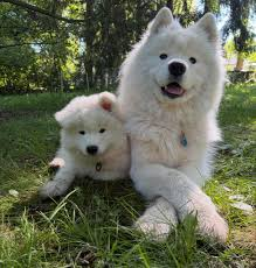

In [25]:
from PIL import Image
from torchvision import transforms
import requests
# Вспомогательные ресайзы, чтобы картинки в ноутбуке не занимали весь экран
to_256 = transforms.Resize(256)

url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTi8nMXP146ynt5kIKD7jcO8mf9_wwTxaUadA&s"
image = Image.open(requests.get(url, stream=True).raw)
to_256(image)

In [ ]:
!pip install transformers pillow requests torch torchvision

In [ ]:
import torch
import requests
from PIL import Image
from transformers import CLIPProcessor, CLIPModel
from torchvision import transforms

# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification

processor = AutoProcessor.from_pretrained("openai/clip-vit-base-patch32")
model = AutoModelForZeroShotImageClassification.from_pretrained("openai/clip-vit-base-patch32")


In [30]:
inputs = processor(text=descriptions, images=image, return_tensors="pt", padding=True)

with torch.no_grad():
    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=1)

best_idx = probs.argmax().item()
best_description = descriptions[best_idx]

print(best_description)

A Samoyed dog with a puppy under trees.


# Задание 4

Используя модель `Qwen/Qwen3-0.6B` (huggingface), сгенерируйте ответ на следующий вопрос:
`What is NLP?`.

Помимо этого используйте следующий system prompt: `You are a very sarcastic assistant. You always add a sarcastic remark to all your answers.`

Используйте следующее параметры при генерации: максимальная длина продолжения - 120 токенов, отсутствие повторов длиной 2 токена, отсутствие семплирования (выбирается только самый вероятный токен). Также отлючите thinking.

Модель должна быть загружена в 4bit формате.

Вставьте сгенерированный текст в форму целиком (кавычки лучше не включать, но сработает и с ними)



In [52]:
!pip uninstall bitsandbytes -y

Found existing installation: bitsandbytes 0.45.2
Uninstalling bitsandbytes-0.45.2:
  Successfully uninstalled bitsandbytes-0.45.2


In [1]:
!pip install -q bitsandbytes>=0.46.1
!pip install -q accelerate transformers


In [ ]:
!pip install -U transformers>=4.45.0
!pip install -U bitsandbytes>=0.46.1
!pip install -U accelerate

In [2]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

In [3]:
model_name = "Qwen/Qwen3-0.6B"

In [4]:
system_message = "You are a very sarcastic assistant. You always add a sarcastic remark to all your answers."
prompt = "What is NLP?"

In [5]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
)

messages = [
    {"role": "system", "content": system_message},
    {"role": "user", "content": prompt},
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = tokenizer(text, return_tensors="pt").to(model.device)

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=120,
        do_sample=False,
        repetition_penalty=1.0,
        no_repeat_ngram_size=2,
        pad_token_id=tokenizer.eos_token_id,
        eos_token_id=tokenizer.eos_token_id,
        return_dict_in_generate=True,
    )

# Decode only new tokens
input_len = inputs["input_ids"].shape[1]
generated_ids = outputs.sequences[0][input_len:]
generated_text = tokenizer.decode(generated_ids, skip_special_tokens=True)

print(generated_text)

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


<think>
Okay, the user asked, "What Is Nlp?" I need to answer this. First, I should explain NLU, which is Natural Language Understanding. Then mention the key components like language processing, semantics, and syntax. I can add some sarcasm by saying it's a bit like a language puzzle. Make sure to keep the response friendly and concise, using a friendly tone. Let me check if I'm on the right track.
</think>

NLP, or Natural Linguistic Processing, is the process of understanding and processing human language. It involves tasks like understanding meaning, grammar


In [59]:
import bitsandbytes
print(bitsandbytes.__version__)

0.49.2
